In [ ]:
import os
import json
import xml.etree.ElementTree as ET

# set the label map for the dataset
# 0: with_mask, 1: without_mask, 2: mask_weared_incorrect
label_map = {
    "with_mask": 0,
    "without_mask": 1,
    "mask_weared_incorrect": 2
}

# EfficientNetB0 + MLP using annotations + split folders

import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Updated paths
current_path = os.getcwd()
BASE_DIR = os.path.join(current_path, "dataset")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")
ANNOTATIONS_DIR = os.path.join(BASE_DIR, "annotations")

In [ ]:
# EfficientNetB0 + MLP using annotations + split folders

import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Updated paths
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")
ANNOTATIONS_DIR = os.path.join(BASE_DIR, "annotations")

# Parse XML to get label for a file
def get_label_from_xml(filename, label_map):
    xml_file = filename.replace(".png", ".xml").replace(".jpg", ".xml")
    xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
    if not os.path.exists(xml_path): return None
    root = ET.parse(xml_path).getroot()
    label = root.find("object/name").text
    return label_map.get(label)

# Load images + labels from a given directory
def load_images_and_labels(image_dir, label_map):
    X, y = [], []
    for fname in os.listdir(image_dir):
        if not fname.endswith((".jpg", ".png")):
            continue
        label_id = get_label_from_xml(fname, label_map)
        if label_id is None:
            continue
        path = os.path.join(image_dir, fname)
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        X.append(img_array)
        y.append(label_id)
    return np.array(X), np.array(y)

# Load the datasets
X_train, y_train = load_images_and_labels(TRAIN_DIR, label_map)
X_valid, y_valid = load_images_and_labels(VALID_DIR, label_map)
X_test, y_test   = load_images_and_labels(TEST_DIR, label_map)


In [ ]:
# Feature extraction using EfficientNetB0
def extract_features(X):
    extractor = EfficientNetB0(include_top=False, weights="imagenet", pooling="avg", input_shape=(224,224,3))
    extractor.trainable = False
    return extractor.predict(X, batch_size=32), extractor.output_shape[1]

X_train_feat, feat_dim = extract_features(X_train)
X_valid_feat, _ = extract_features(X_valid)
X_test_feat, _ = extract_features(X_test)

# Transfer Leaning (MLP) Supervised

def build_classifier(input_dim, num_classes=3):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


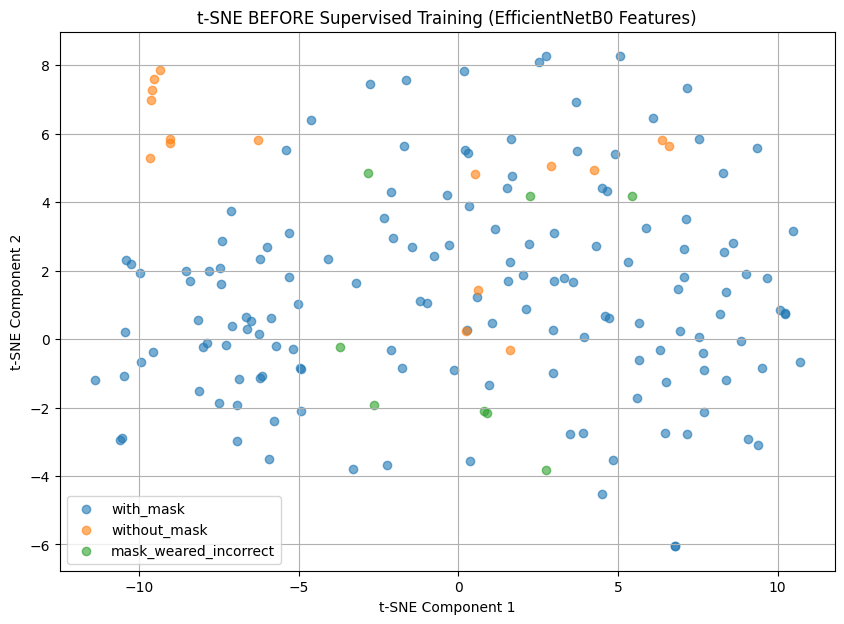

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(features, labels, label_names, title="t-SNE of Extracted Features"):
    # Reduce dimensions to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    features_2d = tsne.fit_transform(features)

    # Plot
    plt.figure(figsize=(10, 7))
    for i, label_name in enumerate(label_names):
        idxs = np.where(labels == i)
        plt.scatter(features_2d[idxs, 0], features_2d[idxs, 1], label=label_name, alpha=0.6)

    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid(True)
    plt.show()

label_names = list(label_map.keys())
plot_tsne(X_test_feat, y_test, label_names, title="t-SNE BEFORE Supervised Training (EfficientNetB0 Features)")



In [ ]:
# Build the classifier model
model = build_classifier(feat_dim)

# Train the model (optional but often necessary before using it)
history = model.fit(X_train_feat, y_train, epochs=10, validation_data=(X_valid_feat, y_valid))


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7903 - loss: 0.6881 - val_accuracy: 0.8176 - val_loss: 0.5813
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9061 - loss: 0.3113 - val_accuracy: 0.8294 - val_loss: 0.5862
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9241 - loss: 0.2640 - val_accuracy: 0.8235 - val_loss: 0.7237
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9269 - loss: 0.1951 - val_accuracy: 0.8353 - val_loss: 0.6214
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9404 - loss: 0.1903 - val_accuracy: 0.8353 - val_loss: 0.6211
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9706 - loss: 0.1063 - val_accuracy: 0.8294 - val_loss: 0.7141
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9563 - loss: 0.1090 - val_accuracy: 0.8353 - val_loss: 0.6903
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9778 - loss: 0.0828 - val_accuracy: 0.8353 - v

In [ ]:
#Evaluate the model
y_pred = np.argmax(model.predict(X_test_feat), axis=1)
probs = model.predict(X_test_feat)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


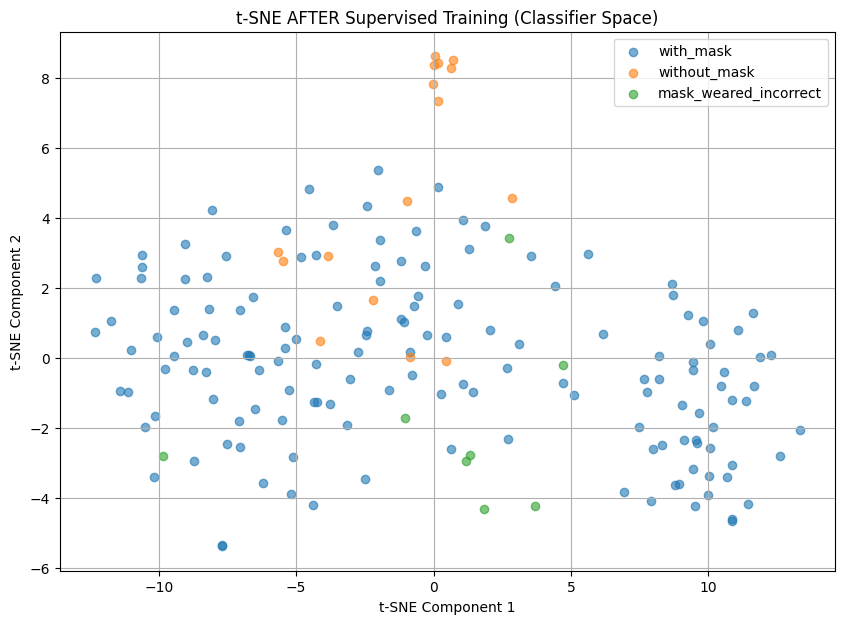

In [ ]:
# Extract outputs from the last hidden layer (before softmax)
intermediate_model = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)
supervised_features = intermediate_model.predict(X_test_feat)


plot_tsne(supervised_features, y_test, label_names, title="t-SNE AFTER Supervised Training (Classifier Space)")


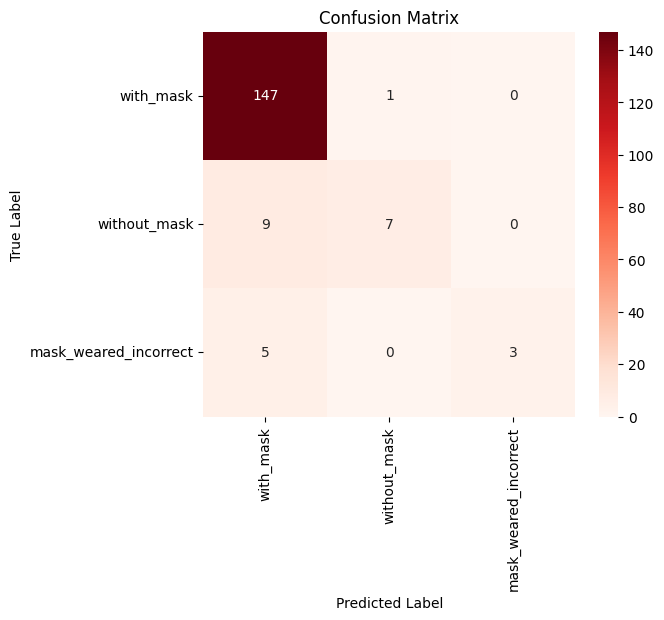

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build readable labels
labels = list(label_map.keys())

# Generate matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot nicely
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


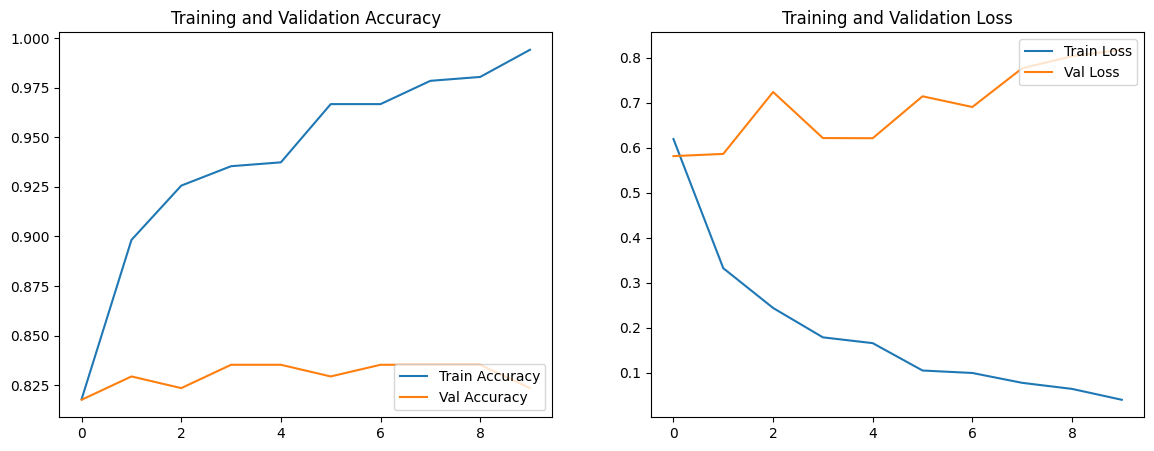

In [ ]:
# Plot Accuracy and Loss
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

plot_history(history)


In [ ]:
import pandas as pd

# Reverse label_map for readability
reverse_label_map = {v: k for k, v in label_map.items()}

# Convert predictions to class names
predicted_labels = [reverse_label_map[p] for p in y_pred]
true_labels = [reverse_label_map[t] for t in y_test]

# Create DataFrame
df_predictions = pd.DataFrame({
    'True Label': true_labels,
    'Predicted Label': predicted_labels
})

# Save to CSV
df_predictions.to_csv("predictions_results.csv", index=False)
print("Predictions exported to predictions_results.csv")


Predictions exported to predictions_results.csv


In [ ]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing.image import load_img

def show_random_images(image_dir, label_map=None, annotation_dir=None, n=9):
    image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png"))]
    sample_files = random.sample(image_files, min(n, len(image_files)))

    plt.figure(figsize=(12, 12))
    for i, fname in enumerate(sample_files):
        path = os.path.join(image_dir, fname)

        # Load image
        img = load_img(path, target_size=(224, 224))

        # Get label if annotations provided
        label = ""
        if label_map and annotation_dir:
            xml_file = fname.replace(".jpg", ".xml").replace(".png", ".xml")
            xml_path = os.path.join(annotation_dir, xml_file)
            if os.path.exists(xml_path):
                tree = ET.parse(xml_path)
                root = tree.getroot()
                label_tag = root.find("object/name")
                if label_tag is not None:
                    label = label_tag.text

        # Plot image
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(label)

    plt.tight_layout()
    plt.show()


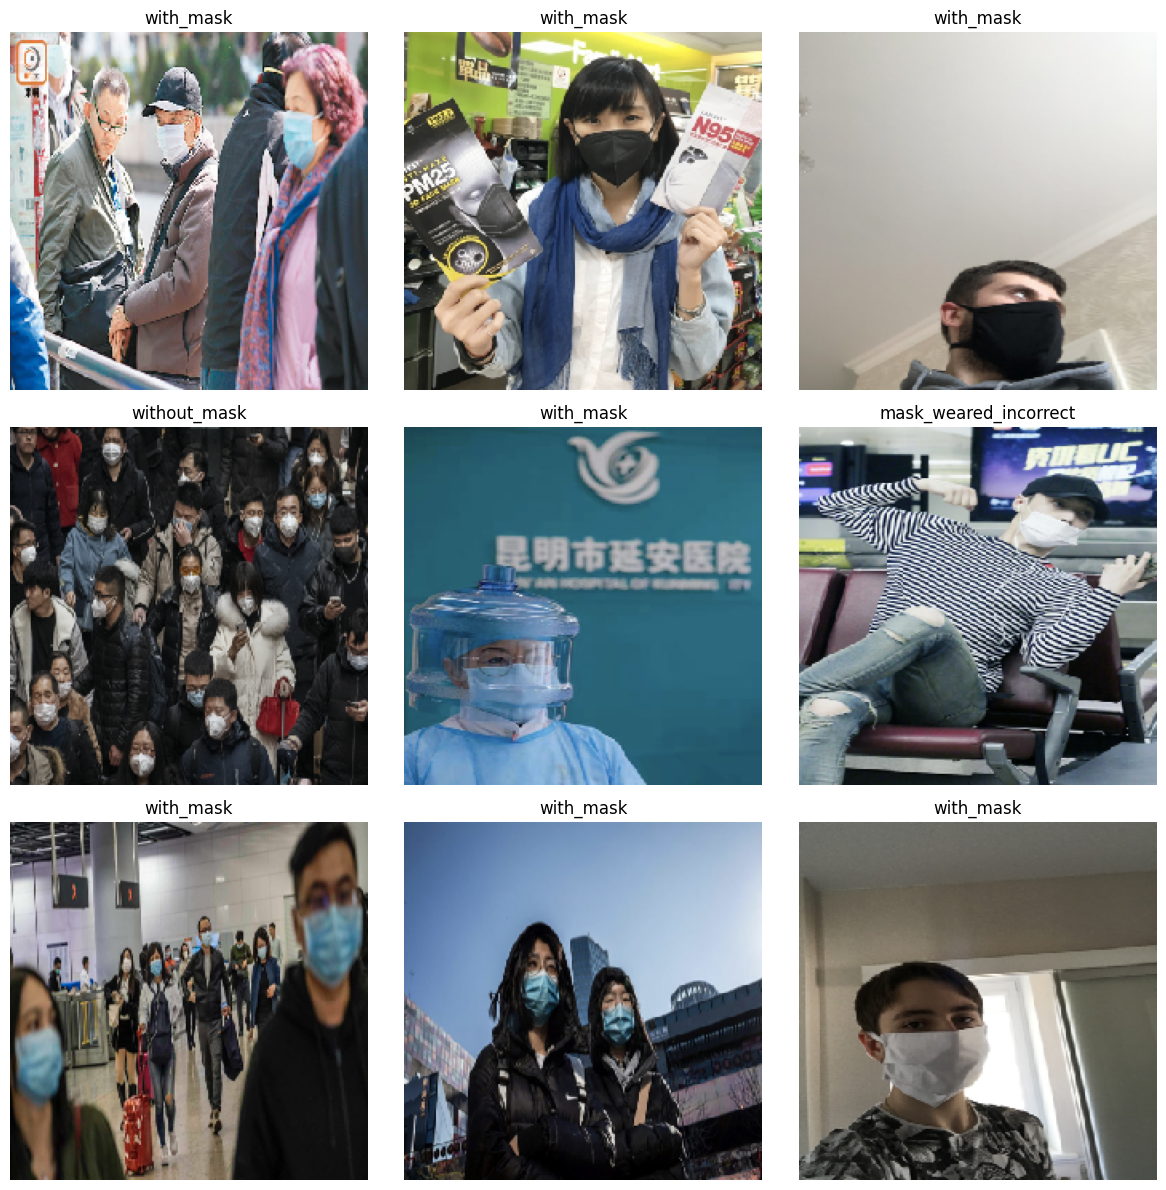

In [ ]:
# View images from the test set with labels from annotations
show_random_images(TEST_DIR, label_map=label_map, annotation_dir=ANNOTATIONS_DIR)


In [ ]:
#display grouped prediction

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import array_to_img

def view_images_by_prediction(X_images, y_true, y_pred, probs, class_names, samples_per_class=5):
    num_classes = len(class_names)
    plt.figure(figsize=(samples_per_class * 3, num_classes * 3))

    for class_id in range(num_classes):
        indices = np.where(y_pred == class_id)[0]
        chosen = np.random.choice(indices, size=min(samples_per_class, len(indices)), replace=False)

        for i, idx in enumerate(chosen):
            plt.subplot(num_classes, samples_per_class, class_id * samples_per_class + i + 1)
            img = array_to_img(X_images[idx])  # Convert from array to image
            plt.imshow(img)
            plt.axis('off')

            confidence = np.max(probs[idx])
            true_class = class_names[y_true[idx]]
            predicted_class = class_names[y_pred[idx]]

            title_color = "green" if y_true[idx] == y_pred[idx] else "red"
            plt.title(f"P: {predicted_class}\nT: {true_class}\nC: {confidence:.2f}", color=title_color, fontsize=8)

    plt.tight_layout()
    plt.show()


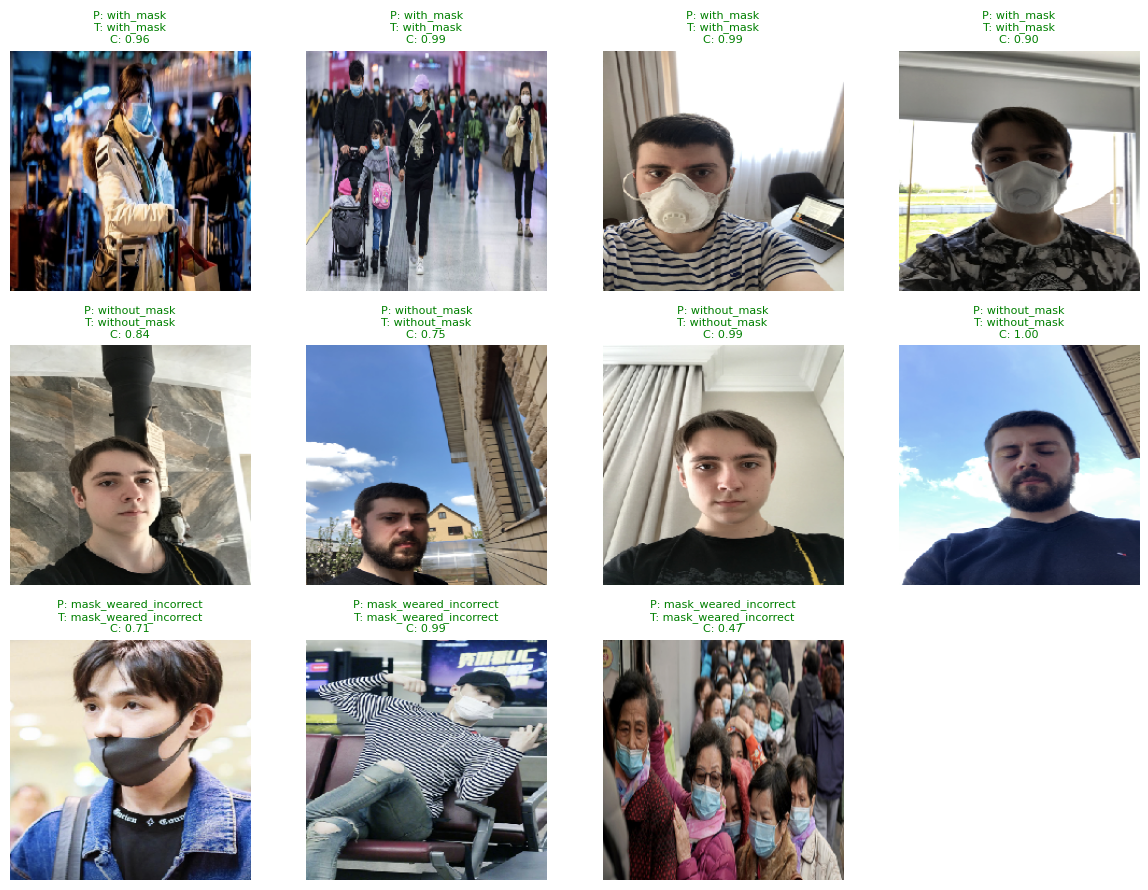

In [ ]:
class_names = list(label_map.keys())

# probs = model.predict(X_test_feat)
# y_pred = np.argmax(probs, axis=1)

view_images_by_prediction(X_test, y_test, y_pred, probs, class_names, samples_per_class=4)
